# Week 3 Day 1: Deep Learning Fundamentals

Every model in Week 2 (Logistic Regression, Decision Tree, Random Forest, etc.) needed hand-engineered features -- we turned headlines into word-count vectors ourselves. Deep learning's whole idea is that the model learns its own useful representations directly from raw data, by stacking small, simple computations on top of each other. A neuron is the smallest one of those computations.

This notebook builds a single neuron completely from scratch, no PyTorch or TensorFlow (that's Day 4) -- just plain NumPy, so the forward pass, loss, backpropagation, and gradient descent are all visible instead of hidden behind a framework call.

In [1]:
import numpy as np

X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([3, 5, 7, 9, 11], dtype=float)
w = 0.0
b = 0.0

Creating the `y = 2x + 1` example to make sure the neuron actually learns and doesn't just luck out. Starting `w` (slope) and `b` (intercept) both at 0 on purpose -- that way any prediction the neuron makes later on has to have come from actual training, not a lucky random starting point.

In [2]:
def forward(X, w, b):
    return X * w + b

predictions = forward(X, w, b)
print("initial Predictions:", predictions)

initial Predictions: [0. 0. 0. 0. 0.]


`forward` is the entire forward propagation step for this neuron -- just `w * X + b`, applied to all 5 points at once. With both parameters still at 0, every prediction comes out as 0, which is expected.

In [3]:
def compute_loss(y, predictions):
    return np.mean((predictions - y) ** 2)

loss = compute_loss(predictions, y)
print("initial Loss:", loss)

initial Loss: 57.0


Loss function to calculate the MSE between the predictions and the actual values -- same metric from Week 2's regression days. The value it gave was 57, which checks out by hand: (0-3)^2 + (0-5)^2 + (0-7)^2 + (0-9)^2 + (0-11)^2 = 285, divided by 5 = 57.

In [4]:
def compute_gradients(X, y, predictions):
    error = predictions - y
    dw = np.mean(2 * error * X)
    db = np.mean(2 * error)
    return dw, db

dw, db = compute_gradients(X, y, predictions)
print("Gradient for w:", dw)
print("Gradient for b:", db)

Gradient for w: -50.0
Gradient for b: -14.0


Backpropagation to calculate the gradients of the loss function with respect to `w` and `b`. This is the chain rule worked out by hand: the loss is `(prediction - y)^2`, so its derivative is `2 * (prediction - y)`. Since `prediction = w*X + b`, nudging `w` changes the prediction by however much `X` is (multiply by `X`), while nudging `b` changes it by exactly 1. Both gradients came out negative, meaning increasing `w` and `b` would decrease the loss -- which makes sense, since both need to grow from 0 toward 2 and 1.

In [5]:
learning_rate = 0.01
epochs = 1000
losses = []
for epoch in range(epochs):
    predictions = forward(X, w, b)
    loss = compute_loss(predictions, y)
    losses.append(loss)
    dw, db = compute_gradients(X, y, predictions)

    w -= learning_rate * dw
    b -= learning_rate * db

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: loss={loss:.4f}, w={w:.4f}, b={b:.4f}")

print(f"\nFinal: w={w:.4f}, b={b:.4f}")

Epoch 0: loss=57.0000, w=0.5000, b=0.1400
Epoch 100: loss=0.0159, w=2.0815, b=0.7058
Epoch 200: loss=0.0081, w=2.0581, b=0.7903
Epoch 300: loss=0.0041, w=2.0414, b=0.8505
Epoch 400: loss=0.0021, w=2.0295, b=0.8935
Epoch 500: loss=0.0011, w=2.0210, b=0.9241
Epoch 600: loss=0.0005, w=2.0150, b=0.9459
Epoch 700: loss=0.0003, w=2.0107, b=0.9614
Epoch 800: loss=0.0001, w=2.0076, b=0.9725
Epoch 900: loss=0.0001, w=2.0054, b=0.9804

Final: w=2.0039, b=0.9860


Actual training loop to update the values of `w` and `b` using gradient descent. Each pass is one full cycle: forward pass (predict), loss (measure how wrong), backward pass (compute gradients), then subtract the gradient from each parameter -- moving opposite the direction that increases loss is literally what "descent" means here. `learning_rate = 0.01` controls how big each step is; it wasn't calculated, just a reasonable starting guess that happened to work well.

`w` ended up at 2.0039 and `b` at 0.9860 -- both very close to the true 2 and 1, with the loss dropping from 57.0 down to basically 0. That's the neuron proving it learned the relationship through repeated small nudges, not by being told the answer.

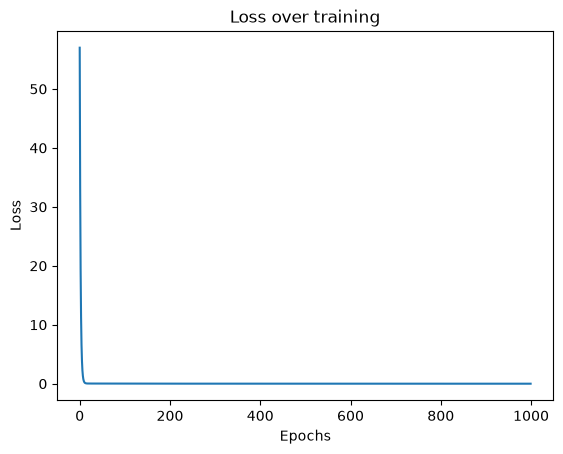

In [6]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss over training")
plt.show()

The loss curve shows the classic gradient descent shape -- a sharp drop in the first ~20 epochs while the parameters are still far from correct, then flattening out as they get close and each step only needs to fine-tune slightly.

## Takeaway

This was a single neuron with no activation function, and that's intentional, not incomplete -- Day 2 introduces activation functions and Day 3 introduces actual multiple layers. Today was about the mechanics underneath all of that: forward pass, loss, backpropagation, and gradient descent, built by hand instead of hidden behind a framework function. Every deep learning model, no matter how many layers or how complex, is running this exact same loop underneath -- just with a lot more neurons and parameters at once.